# 07 — Structure Visualization

Paper-style figure comparing all 4 variants (Base, Base+Viterbi, CTL, CTL+Viterbi)
for any song: mel-spectrogram, boundary curves, function curves, and label bars.

## Setup

In [1]:
import sys, os
import numpy as np
import torch
import librosa
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
sys.path.insert(0, os.path.abspath(".."))

from utils.label_conversion import CLASSES, convert_segments
from utils.dataset import MELSPEC_DIR, SEGMENT_DIR
from utils.spectnt import SpecTNT
from utils.postprocessing import postprocess
from utils.smoothing import compute_transition_matrix, smoothed_postprocess
from utils.target_generation import TARGET_FPS, NATIVE_FPS
from utils.metrics import evaluate_song

device = torch.device("xpu" if torch.xpu.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"TARGET_FPS: {TARGET_FPS:.2f}, NATIVE_FPS: {NATIVE_FPS:.2f}")
print(f"Classes: {CLASSES}")

Device: cuda
TARGET_FPS: 5.38, NATIVE_FPS: 21.53
Classes: ['intro', 'verse', 'chorus', 'bridge', 'outro', 'inst', 'silence']


## Song Selection

In [2]:
SID = "0024_billionaire"   # Change this to visualize any song
FOLD = 2                # Which fold's checkpoint to use (1-4)
SAVE_DIR = "../checkpoints"

print(f"Visualizing: {SID}, Fold: {FOLD}")

Visualizing: 0024_billionaire, Fold: 2


## Inference Utility

In [3]:
def infer_full_song(model, sid, chunk_frames=130):
    """Run SpecTNT on a full song chunk-by-chunk, average overlapping regions.

    Returns:
        b_logits: (T, 1) boundary logits at target FPS
        f_logits: (T, 7) function logits at target FPS
        melspec: (80, T_native) raw mel spectrogram
    """
    melspec = np.load(os.path.join(MELSPEC_DIR, f"{sid}-mel.npy"))
    total_native = melspec.shape[1]
    total_target = total_native // 4

    all_b = np.zeros((total_target, 1), dtype=np.float32)
    all_f = np.zeros((total_target, 7), dtype=np.float32)
    counts = np.zeros(total_target, dtype=np.float32)

    hop = chunk_frames // 4
    for start in range(0, total_target - chunk_frames + 1, hop):
        native_start = start * 4
        native_end = native_start + chunk_frames * 4
        if native_end > total_native:
            break
        chunk = melspec[:, native_start:native_end]
        chunk_t = torch.from_numpy(chunk).unsqueeze(0).unsqueeze(0).float().to(device)
        with torch.no_grad():
            b, f = model(chunk_t)
        b = b.squeeze(0).cpu().numpy()
        f = f.squeeze(0).cpu().numpy()
        end = min(start + chunk_frames, total_target)
        seg_len = end - start
        all_b[start:end] += b[:seg_len]
        all_f[start:end] += f[:seg_len]
        counts[start:end] += 1

    mask = counts > 0
    all_b[mask] /= counts[mask, None]
    all_f[mask] /= counts[mask, None]
    return all_b, all_f, melspec

## Load Ground Truth

In [4]:
def load_ground_truth(sid):
    """Load and convert ground truth segments for a song."""
    boundaries_ref = []
    labels_ref = []
    seg_path = os.path.join(SEGMENT_DIR, f"{sid}.txt")
    with open(seg_path, encoding="utf-8", errors="replace") as f:
        for line in f:
            parts = line.strip().split(maxsplit=1)
            if len(parts) == 2:
                boundaries_ref.append(float(parts[0]))
                labels_ref.append(parts[1].strip())
    labels_ref = [l for l in labels_ref if l != "end"]
    conv_labels, _ = convert_segments(boundaries_ref[:-1], labels_ref)
    return boundaries_ref, conv_labels

boundaries_ref, conv_labels = load_ground_truth(SID)
print(f"GT segments: {len(conv_labels)}")
for b, l in zip(boundaries_ref, conv_labels + ['']):
    print(f"  {b:>7.2f}s  {l}")

GT segments: 9
     0.00s  silence
     5.45s  verse
    27.52s  chorus
    50.93s  verse
    85.42s  chorus
   117.14s  verse
   151.63s  verse
   173.71s  chorus
   206.78s  outro
   212.26s  


## Run All 4 Variants

In [5]:
def run_variant(variant, fold, sid, trans_mat=None):
    """Load checkpoint, run inference, postprocess, and evaluate.

    Args:
        variant: 'base' or 'ctl'
        fold: fold number (1-4)
        sid: song ID
        trans_mat: transition matrix for Viterbi (optional, uses baseline if None)

    Returns:
        dict with keys: boundaries, labels, metrics, b_logits, f_logits
    """
    ckpt_path = os.path.join(SAVE_DIR, f"spectnt_{variant}_fold{fold}.pt")
    model = SpecTNT().to(device)
    ckpt = torch.load(ckpt_path, map_location=device)
    state_dict = {k.replace("_orig_mod.", ""): v for k, v in ckpt["model_state"].items()}
    model.load_state_dict(state_dict)
    model.eval()

    b_logits, f_logits, melspec = infer_full_song(model, sid)

    if trans_mat is not None:
        boundaries, labels, _ = smoothed_postprocess(
            b_logits.squeeze(-1), f_logits, trans_mat, fps=TARGET_FPS,
        )
    else:
        boundaries, labels, _ = postprocess(
            b_logits.squeeze(-1), f_logits, fps=TARGET_FPS,
        )

    metrics = evaluate_song(boundaries, labels, boundaries_ref, conv_labels)

    return {
        "boundaries": boundaries,
        "labels": labels,
        "metrics": metrics,
        "b_logits": b_logits,
        "f_logits": f_logits,
        "melspec": melspec,
    }

# Compute transition matrix from all songs for Viterbi smoothing
import pandas as pd
META_PATH = os.path.abspath("../data/harmonixset/dataset/metadata.csv")
meta_df = pd.read_csv(META_PATH, encoding="utf-8", encoding_errors="replace")
all_ids = meta_df["File"].tolist()
trans_mat = compute_transition_matrix(all_ids, SEGMENT_DIR, self_loop_prior=50.0)
print("Transition matrix computed.")

# Run all 4 variants
print(f"\nRunning variants for {SID}...")
results = {}
configs = [
    ("base", "Base", None),
    ("base", "Base+Viterbi", trans_mat),
    ("ctl",  "CTL", None),
    ("ctl",  "CTL+Viterbi", trans_mat),
]
for variant, name, tmat in configs:
    res = run_variant(variant, FOLD, SID, tmat)
    results[name] = res
    m = res["metrics"]
    print(f"  {name:<15} HR@0.5={m['hr.5f']:.4f}  ACC={m['acc']:.4f}  PWF={m['pwf']:.4f}  Sf={m['sf']:.4f}  CF1={m['cf1']:.4f}")

# Also store melspec and native time (same for all variants)
melspec = results["Base"]["melspec"]
native_time = np.arange(melspec.shape[1]) / NATIVE_FPS
target_time = np.arange(results["Base"]["b_logits"].shape[0]) / TARGET_FPS

Transition matrix computed.

Running variants for 0024_billionaire...
  Base            HR@0.5=0.2667  ACC=0.4564  PWF=0.6258  Sf=0.1736  CF1=0.6397
  Base+Viterbi    HR@0.5=0.2667  ACC=0.4560  PWF=0.5358  Sf=0.0594  CF1=0.5575
  CTL             HR@0.5=0.2540  ACC=0.5464  PWF=0.5244  Sf=0.0808  CF1=0.5480
  CTL+Viterbi     HR@0.5=0.2540  ACC=0.5864  PWF=0.5160  Sf=0.0981  CF1=0.5470


## Visualization Helpers

In [6]:
COLORS = ["cyan", "lime", "yellow", "orange", "magenta", "red", "blue"]

def draw_label_bar(ax, boundaries, labels, y_pos=0.5, height=0.8, alpha=0.7, fontsize=8):
    """Draw a colored segment bar on an axis.

    Args:
        ax: matplotlib axis
        boundaries: list of boundary timestamps (seconds)
        labels: list of segment label strings
        y_pos: center y-position of the bar
        height: total height of the bar
        alpha: color transparency
        fontsize: label text size
    """
    for i in range(len(boundaries) - 1):
        s, e = boundaries[i], boundaries[i + 1]
        cls_idx = CLASSES.index(labels[i]) if labels[i] in CLASSES else -1
        if cls_idx >= 0:
            ax.axvspan(s, e, ymin=y_pos - height / 2, ymax=y_pos + height / 2,
                       alpha=alpha, color=COLORS[cls_idx], edgecolor="none")
            mid = (s + e) / 2
            if (e - s) > 5:  # only label segments wider than 5s
                ax.text(mid, y_pos, labels[i], ha="center", va="center",
                        fontsize=fontsize, rotation=90, fontweight="bold")


def draw_boundary_lines(ax, boundaries, color="black", linestyle="--", alpha=0.7, ymin=0, ymax=1):
    """Draw vertical dashed lines at boundary positions."""
    for b in boundaries[1:-1]:  # skip first (0) and last (song end)
        ax.axvline(b, color=color, linestyle=linestyle, alpha=alpha, linewidth=0.8)


def draw_boundary_curve(ax, b_logits, target_time):
    """Draw the boundary activation curve (sigmoid of logits)."""
    b_probs = 1.0 / (1.0 + np.exp(-b_logits.squeeze(-1)))
    ax.plot(target_time, b_probs, color="tab:blue", linewidth=1.2)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Boundary", fontsize=9)
    ax.tick_params(axis="y", labelsize=8)


def draw_function_curves(ax, f_logits, target_time):
    """Draw softmax function curves with vertical offset."""
    for i, cls_name in enumerate(CLASSES):
        f_probs = 1.0 / (1.0 + np.exp(-f_logits[:, i]))
        ax.plot(target_time, f_probs + (i + 1) * 1.3, color=COLORS[i],
                linewidth=1.0, alpha=0.85, label=cls_name)
    ax.set_ylabel("Function\n(+offset)", fontsize=9)
    ax.set_yticks([])
    ax.tick_params(axis="y", labelsize=8)


def make_legend(fig, axes):
    """Add a shared legend below the figure."""
    handles = [mpatches.Patch(color=COLORS[i], label=CLASSES[i]) for i in range(len(CLASSES))]
    fig.legend(handles=handles, loc="lower center", ncol=len(CLASSES),
               fontsize=9, frameon=True, fancybox=True)

## Figure 1 — Detailed View (Paper-Style)

5 panels for the **Base** variant: mel-spectrogram, boundary curve, function curves,
raw labels, and post-processed labels with ground truth.

/home/fharook/Documents/BTU/BTU_RM_So26/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_13832/298393666.py:44: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax3.axvspan(s_sec, e_sec, alpha=0.7, color=COLORS[cls_idx], edgecolor="none")
/tmp/ipykernel_13832/915927756.py:19: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(s, e, ymin=y_pos - height / 2, ymax=y_pos + height / 2,


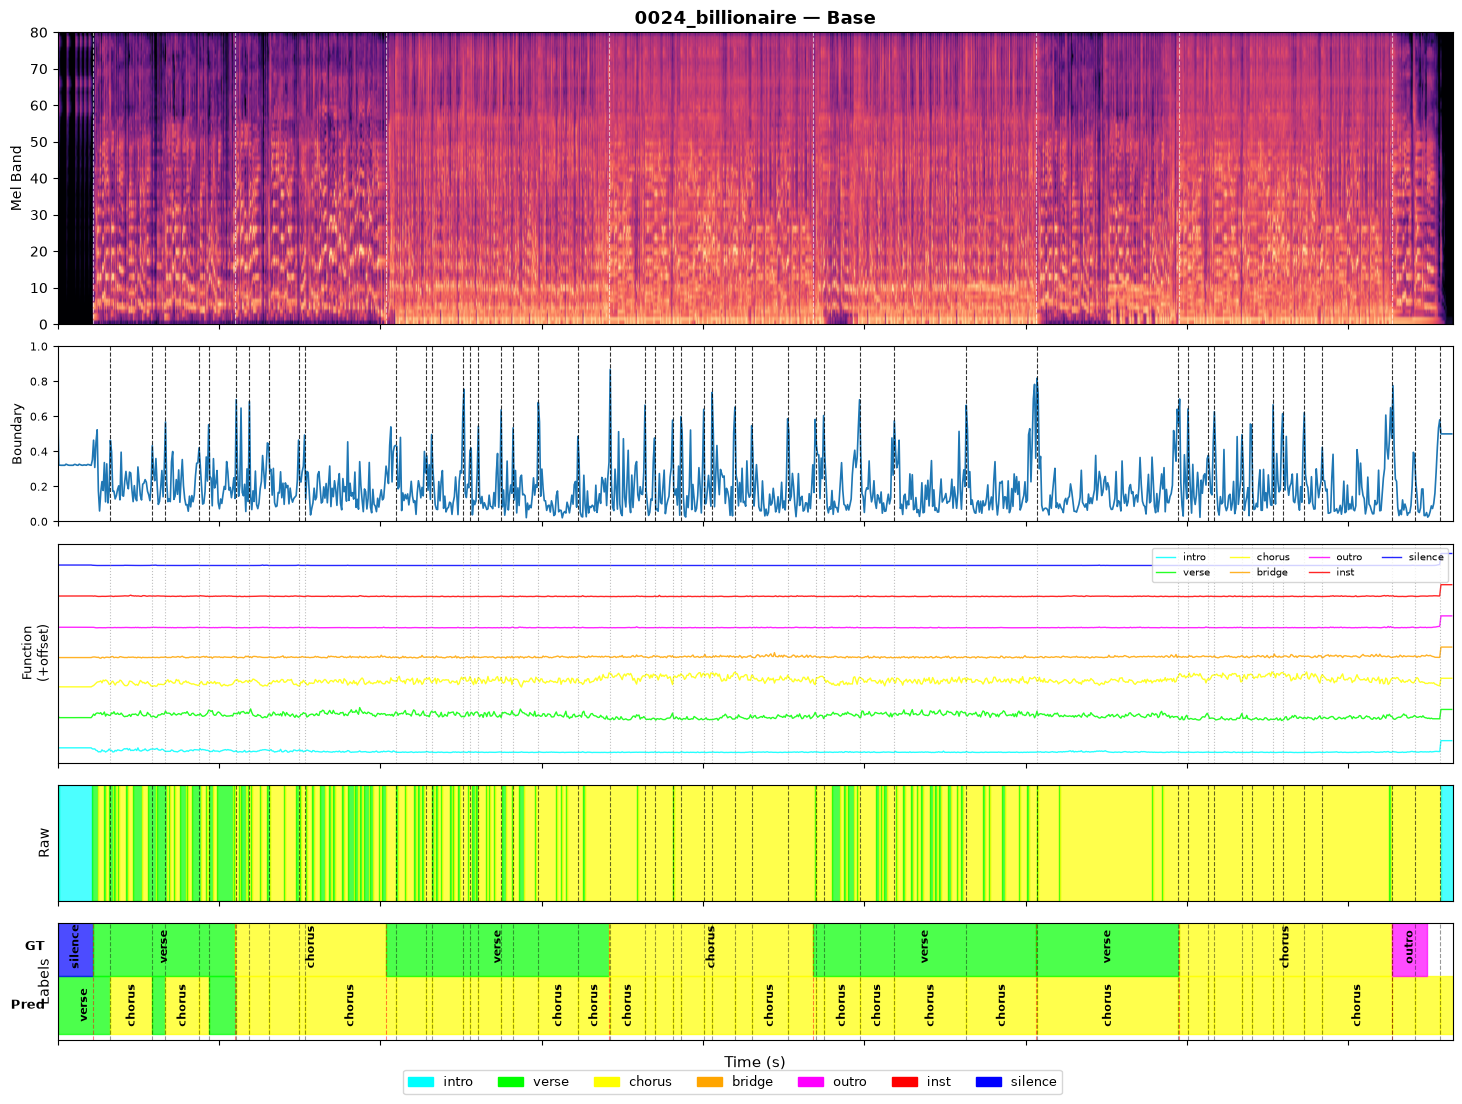

In [7]:
# Select which variant to show in detail
DETAIL_VARIANT = "Base"  # Options: Base, Base+Viterbi, CTL, CTL+Viterbi
res = results[DETAIL_VARIANT]

fig = plt.figure(figsize=(18, 12))
gs = GridSpec(5, 1, figure=fig, height_ratios=[2, 1.2, 1.5, 0.8, 0.8], hspace=0.12)

# --- Panel 1: Mel Spectrogram ---
ax0 = fig.add_subplot(gs[0])
melspec_db = librosa.power_to_db(melspec)
ax0.imshow(melspec_db, aspect="auto", origin="lower",
           extent=[0, native_time[-1], 0, 80], cmap="magma")
ax0.set_ylabel("Mel Band", fontsize=10)
ax0.set_title(f"{SID} — {DETAIL_VARIANT}", fontsize=13, fontweight="bold")
ax0.set_xlim(0, native_time[-1])
draw_boundary_lines(ax0, boundaries_ref, color="white", linestyle="--", alpha=0.6)
ax0.set_xticklabels([])

# --- Panel 2: Boundary Curve + Predicted Boundaries ---
ax1 = fig.add_subplot(gs[1], sharex=ax0)
draw_boundary_curve(ax1, res["b_logits"], target_time)
draw_boundary_lines(ax1, res["boundaries"], color="black", linestyle="--", alpha=0.8)
ax1.set_xticklabels([])

# --- Panel 3: Function Curves ---
ax2 = fig.add_subplot(gs[2], sharex=ax0)
draw_function_curves(ax2, res["f_logits"], target_time)
draw_boundary_lines(ax2, res["boundaries"], color="gray", linestyle=":", alpha=0.5)
ax2.set_xticklabels([])
ax2.legend(loc="upper right", ncol=4, fontsize=7, framealpha=0.8)

# --- Panel 4: Raw Function Labels (argmax) ---
ax3 = fig.add_subplot(gs[3], sharex=ax0)
function_probs = 1.0 / (1.0 + np.exp(-res["f_logits"]))
raw_labels = [CLASSES[np.argmax(function_probs[t])] for t in range(len(function_probs))]
# Draw raw labels as a continuous bar by finding contiguous runs
run_start = 0
for t in range(1, len(raw_labels) + 1):
    if t == len(raw_labels) or raw_labels[t] != raw_labels[run_start]:
        s_sec = run_start / TARGET_FPS
        e_sec = t / TARGET_FPS
        cls_idx = CLASSES.index(raw_labels[run_start]) if raw_labels[run_start] in CLASSES else -1
        if cls_idx >= 0:
            ax3.axvspan(s_sec, e_sec, alpha=0.7, color=COLORS[cls_idx], edgecolor="none")
        run_start = t
ax3.set_ylabel("Raw", fontsize=10)
ax3.set_yticks([])
ax3.set_xticklabels([])
draw_boundary_lines(ax3, res["boundaries"], color="black", linestyle="--", alpha=0.6)

# --- Panel 5: Post-Processed Labels + Ground Truth ---
ax4 = fig.add_subplot(gs[4], sharex=ax0)
# Predicted
draw_label_bar(ax4, res["boundaries"], res["labels"], y_pos=0.3, height=0.5)
ax4.text(-2, 0.3, "Pred", ha="right", va="center", fontsize=9, fontweight="bold")
# Ground truth
draw_label_bar(ax4, boundaries_ref, conv_labels, y_pos=0.8, height=0.5)
ax4.text(-2, 0.8, "GT", ha="right", va="center", fontsize=9, fontweight="bold")
draw_boundary_lines(ax4, boundaries_ref, color="red", linestyle="--", alpha=0.5)
draw_boundary_lines(ax4, res["boundaries"], color="black", linestyle="--", alpha=0.4)
ax4.set_ylabel("Labels", fontsize=10)
ax4.set_yticks([])
ax4.set_xlabel("Time (s)", fontsize=11)

# Common x-axis limits
for ax in [ax0, ax1, ax2, ax3, ax4]:
    ax.set_xlim(0, native_time[-1])

# Legend
handles = [mpatches.Patch(color=COLORS[i], label=CLASSES[i]) for i in range(len(CLASSES))]
fig.legend(handles=handles, loc="lower center", ncol=len(CLASSES), fontsize=9,
           frameon=True, fancybox=True, bbox_to_anchor=(0.5, -0.01))

plt.subplots_adjust(bottom=0.04)
plt.show()

## Figure 2 — 4-Variant Comparison

Compact view: mel-spectrogram, ground truth, and prediction bars for all 4 variants.

/tmp/ipykernel_13832/915927756.py:19: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(s, e, ymin=y_pos - height / 2, ymax=y_pos + height / 2,
/tmp/ipykernel_13832/915927756.py:19: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(s, e, ymin=y_pos - height / 2, ymax=y_pos + height / 2,
/tmp/ipykernel_13832/915927756.py:19: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(s, e, ymin=y_pos - height / 2, ymax=y_pos + height / 2,
/tmp/ipykernel_13832/915927756.py:19: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(s, e, ymin=y_pos - height / 2, ymax=y_pos + height / 2,
/tmp/ipykernel_13832/915927756.py:19: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(s, e, ymin=y_pos - height / 2, ymax=y_pos + he

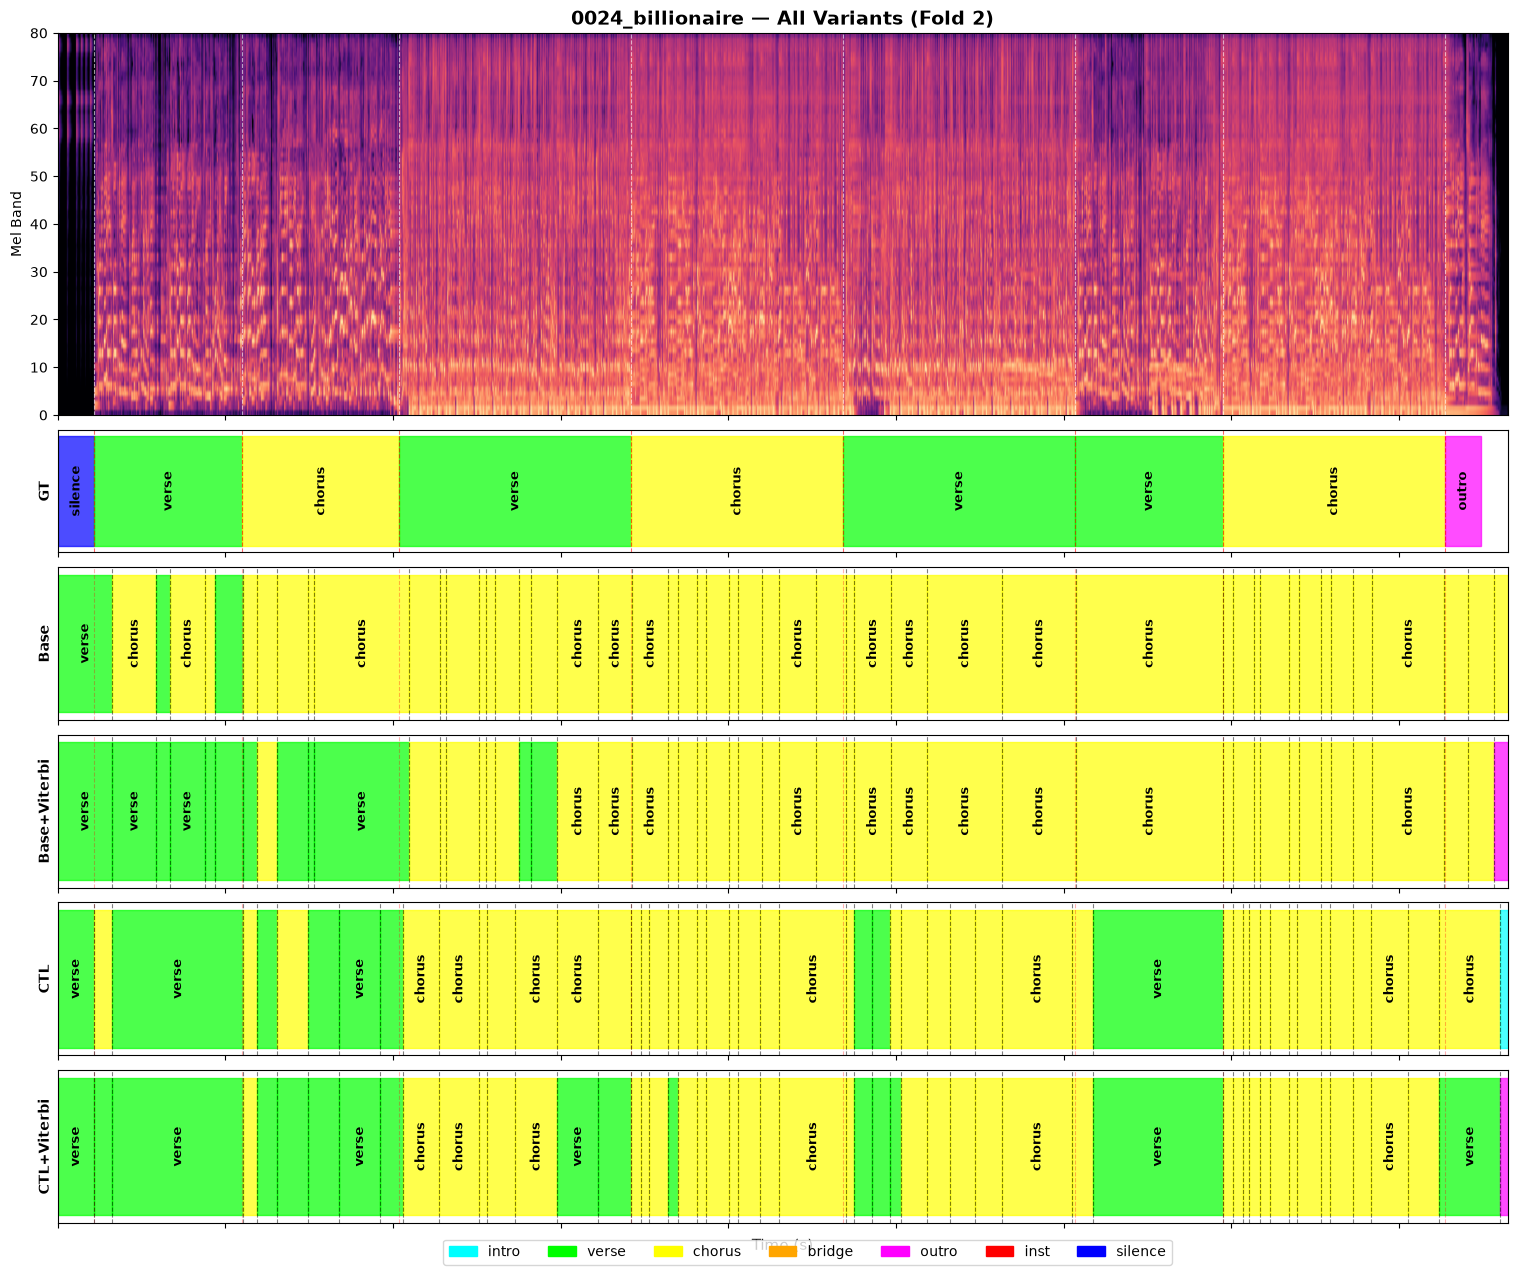

In [11]:
variant_order = ["Base", "Base+Viterbi", "CTL", "CTL+Viterbi"]

fig = plt.figure(figsize=(20, 14))
gs = GridSpec(6, 1, figure=fig, height_ratios=[2.5, 0.8, 1.0, 1.0, 1.0, 1.0], hspace=0.08)

# --- Row 0: Mel Spectrogram ---
ax_mel = fig.add_subplot(gs[0])
melspec_db = librosa.power_to_db(melspec)
ax_mel.imshow(melspec_db, aspect="auto", origin="lower",
              extent=[0, native_time[-1], 0, 80], cmap="magma")
ax_mel.set_ylabel("Mel Band", fontsize=10)
ax_mel.set_title(f"{SID} — All Variants (Fold {FOLD})", fontsize=14, fontweight="bold")
ax_mel.set_xlim(0, native_time[-1])
draw_boundary_lines(ax_mel, boundaries_ref, color="white", linestyle="--", alpha=0.6)
ax_mel.set_xticklabels([])

# --- Row 1: Ground Truth ---
ax_gt = fig.add_subplot(gs[1], sharex=ax_mel)
draw_label_bar(ax_gt, boundaries_ref, conv_labels, y_pos=0.5, height=0.9, fontsize=9)
draw_boundary_lines(ax_gt, boundaries_ref, color="red", linestyle="--", alpha=0.6)
ax_gt.set_ylabel("GT", fontsize=10, fontweight="bold")
ax_gt.set_yticks([])
ax_gt.set_xticklabels([])

# --- Rows 2-5: One row per variant ---
for row_idx, variant_name in enumerate(variant_order):
    ax = fig.add_subplot(gs[2 + row_idx], sharex=ax_mel)
    res = results[variant_name]

    draw_label_bar(ax, res["boundaries"], res["labels"], y_pos=0.5, height=0.9, fontsize=9)
    draw_boundary_lines(ax, boundaries_ref, color="red", linestyle="--", alpha=0.3)
    draw_boundary_lines(ax, res["boundaries"], color="black", linestyle="--", alpha=0.5)

    m = res["metrics"]
    # label = f"{variant_name}  |  HR@0.5={m['hr.5f']:.3f}  ACC={m['acc']:.3f}  PWF={m['pwf']:.3f}  Sf={m['sf']:.3f}  CF1={m['cf1']:.3f}"
    ax.set_ylabel(variant_name, fontsize=10, fontweight="bold")
    # ax.text(1.01, 0.5, label, transform=ax.transAxes, va="center", fontsize=8,
    #         fontfamily="monospace", bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))
    ax.set_yticks([])
    if row_idx < len(variant_order) - 1:
        ax.set_xticklabels([])
    else:
        ax.set_xlabel("Time (s)", fontsize=11)

# Common x-axis
for ax in [ax_mel, ax_gt] + [fig.axes[i] for i in range(2, len(fig.axes))]:
    ax.set_xlim(0, native_time[-1])

# Legend
handles = [mpatches.Patch(color=COLORS[i], label=CLASSES[i]) for i in range(len(CLASSES))]
fig.legend(handles=handles, loc="lower center", ncol=len(CLASSES), fontsize=10,
           frameon=True, fancybox=True, bbox_to_anchor=(0.5, -0.005))

plt.subplots_adjust(bottom=0.03, right=0.85)
plt.show()

## Metrics Summary Table

In [9]:
print(f"\n{'='*90}")
print(f"  Song: {SID}  |  Fold: {FOLD}")
print(f"{'='*90}")
print(f"  {'Variant':<17} {'HR@0.5':>7} {'ACC':>7} {'PWF':>7} {'Sf':>7} {'CHR@0.5':>8} {'CF1':>7} {'MF1':>7} {'#Seg':>5}")
print(f"  {'-'*83}")
for variant_name in ["Base", "Base+Viterbi", "CTL", "CTL+Viterbi"]:
    m = results[variant_name]["metrics"]
    n_seg = len(results[variant_name]["labels"])
    print(f"  {variant_name:<17} {m['hr.5f']:>7.4f} {m['acc']:>7.4f} {m['pwf']:>7.4f} {m['sf']:>7.4f} {m['chr.5f']:>8.4f} {m['cf1']:>7.4f} {m['macro_f1']:>7.4f} {n_seg:>5}")
print(f"  {'-'*83}")
gt_n_seg = len(conv_labels)
gt_durs = [boundaries_ref[i+1] - boundaries_ref[i] for i in range(len(boundaries_ref)-1)]
print(f"  {'Ground Truth':<17} {'':>7} {'':>7} {'':>7} {'':>7} {'':>8} {'':>7} {'':>7} {gt_n_seg:>5}")
print(f"\n  GT: {gt_n_seg} segments, median duration {np.median(gt_durs):.1f}s")
for variant_name in ["Base", "Base+Viterbi", "CTL", "CTL+Viterbi"]:
    b = results[variant_name]["boundaries"]
    seg_durs = [b[i+1] - b[i] for i in range(len(b)-1)]
    ratio = len(results[variant_name]["labels"]) / gt_n_seg
    print(f"  {variant_name}: {len(results[variant_name]['labels'])} segments, median {np.median(seg_durs):.1f}s, {ratio:.1f}x over-seg")


  Song: 0024_billionaire  |  Fold: 2
  Variant            HR@0.5     ACC     PWF      Sf  CHR@0.5     CF1     MF1  #Seg
  -----------------------------------------------------------------------------------
  Base               0.2667  0.4564  0.6258  0.1736   0.1786  0.6397  0.1079    50
  Base+Viterbi       0.2667  0.4560  0.5358  0.0594   0.1739  0.5575  0.1283    50
  CTL                0.2540  0.5464  0.5244  0.0808   0.1455  0.5480  0.1581    53
  CTL+Viterbi        0.2540  0.5864  0.5160  0.0981   0.1667  0.5470  0.1720    53
  -----------------------------------------------------------------------------------
  Ground Truth                                                                   9

  GT: 9 segments, median duration 23.4s
  Base: 50 segments, median 3.5s, 5.6x over-seg
  Base+Viterbi: 50 segments, median 3.5s, 5.6x over-seg
  CTL: 53 segments, median 3.2s, 5.9x over-seg
  CTL+Viterbi: 53 segments, median 3.2s, 5.9x over-seg


## Try Another Song

Re-run the cells above after changing `SID` and/or `FOLD`.

In [10]:
# List available songs for reference
import pandas as pd
meta = pd.read_csv(META_PATH, encoding="utf-8", encoding_errors="replace")
print(f"Available songs: {len(meta)}")
print(meta[["File", "Genre", "Artist", "Title"]].head(20).to_string(index=False))

Available songs: 912
                  File            Genre                        Artist                                   Title
           0001_12step              R&B                         Ciara                               1, 2 Step
       0003_6foot7foot          Hip-Hop                     Lil Wayne                           6 Foot 7 Foot
              0004_abc         Pop-Rock                 The Jackson 5                                     ABC
            0005_again      Alternative                       Flyleaf                                   Again
   0006_aint2proud2beg              R&B                           TLC                     Ain’t 2 Proud 2 Beg
          0008_america            Metal                   Spın̈al Tap                                 America
    0009_americanmusic      Alternative                Violent Femmes                          American Music
 0010_andjusticeforall            Metal                     Metallica     ...and Justice for All (L